# QuanONet operator learning visualization Demo

This Notebook provides a complete visual demonstration of the three PDE operator learning problems reported in the paper.

# 1. Initialize the environment and load general functions

In [18]:
import os
import numpy as np
import mindspore as ms
from mindspore import load_checkpoint, load_param_into_net, context
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp

# Import the data generator, model and Hamiltonian generation logic
from data_utils.data_generation import generate_random_gaussian_field, ODE_SYSTEMS
from data_utils.data_generation import solve_darcy_pde, solve_advection_pde, solve_rdiffusion_pde
from core.models import QuanONet
from core.quantum_circuits import generate_simple_hamiltonian

# 1. Set up MindSpore context and Matplotlib style
context.set_context(mode=ms.context.PYNATIVE_MODE, device_target="CPU")
plt.rcdefaults()
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

def plot_operator_result(operator_name, true_sol, pred_sol, u0_func_np, x_grid, other_grid, mae, mse):
    """
    operator_name: Antideriv, Homogeneous, Darcy, Advection, etc.
    true_sol: Grid (num_points, num_points) or Array (num_points,)
    pred_sol: Grid or Array
    u0_func_np: The input function on sensor points
    x_grid: The spatial meshgrid (X_grid)
    other_grid: The time or y meshgrid (T_grid or Y_grid)
    """
    num_points = len(x_grid)
    num_points_0 = len(u0_func_np)
    x_cal_0 = np.linspace(0, 1, num_points_0).astype(np.float32)
    true_sol.ndim == 2
    
    
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    
    vmin = min(true_sol.min(), pred_sol.min())
    vmax = max(true_sol.max(), pred_sol.max())
    
    ylabel = r"$t$" if operator_name != 'Darcy' else r"$y$"
        
    # 1. Input u0
    axes[0].plot(x_cal_0, u0_func_np, 'k-', linewidth=2.5)
    axes[0].set_title(r"Input $u_0(x)$", fontsize=16)
    axes[0].set_xlabel(r"$x$", fontsize=16)
    axes[0].set_ylabel(r"$u_0$", fontsize=16)
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # 2. Ground Truth
    h1 = axes[1].contourf(x_grid, other_grid, true_sol, 100, cmap='jet', vmin=vmin, vmax=vmax)
    axes[1].set_ylabel(ylabel, fontsize=16)
    fig.colorbar(h1, ax=axes[1], fraction=0.046, pad=0.04)
    axes[1].set_title("Ground Truth", fontsize=16)
    axes[1].set_xlabel(r"$x$", fontsize=16)

    # 3. Prediction
    h2 = axes[2].contourf(x_grid, other_grid, pred_sol, 100, cmap='jet', vmin=vmin, vmax=vmax)
    axes[2].set_ylabel(ylabel, fontsize=16)
    fig.colorbar(h2, ax=axes[2], fraction=0.046, pad=0.04)
    axes[2].set_title(f"Prediction (MSE={mse:.1e})", fontsize=16)
    axes[2].set_xlabel(r"$x$", fontsize=16)

    # 4. Abs. Error
    abs_error_grid = np.abs(true_sol - pred_sol)
    h3 = axes[3].contourf(x_grid, other_grid, abs_error_grid, 100, cmap='jet')
    axes[3].set_ylabel(ylabel, fontsize=16)
    fig.colorbar(h3, ax=axes[3], fraction=0.046, pad=0.04)
    axes[3].set_title(f"Abs. Error (MAE={mae:.1e})", fontsize=16)
    axes[3].set_xlabel(r"$x$", fontsize=16)

    plt.suptitle(f"[{operator_name}] Operator Demonstration", fontsize=20, y=1.02, fontweight='bold')
    plt.tight_layout()
    plt.show()

[WARNING] ME(14300:8266395776,MainProcess):2026-03-25-17:13:36.928.215 [mindspore/context.py:1334] For 'context.set_context', the parameter 'device_target' will be deprecated and removed in a future version. Please use the api mindspore.set_device() instead.


## 2. Problem configuration mapping and weight path

In [19]:
problem_configs = {
    'Advection': {
        'ckpt_path': "Table4_Reproduction/Advection/Advection_QuanONet_Net40-2-20-2_Q5_TF_S0.1_1000x100_Seed0/best_model.ckpt",
        'num_qubits': 5, 'net_size': (40, 2, 20, 2), 'scale_coeff': 0.1,
        'pde_solver': solve_advection_pde,
        'solver_args': {'c': 1.0}
    },
    'RDiffusion': {
        'ckpt_path': "Table4_Reproduction/RDiffusion/RDiffusion_QuanONet_Net40-2-20-2_Q5_TF_S0.1_1000x100_Seed0/best_model.ckpt",
        'num_qubits': 5, 'net_size': (40, 2, 20, 2), 'scale_coeff': 0.1,
        'pde_solver': solve_rdiffusion_pde,
        'solver_args': {'D': 0.01, 'k': 0.01}
    },
    'Darcy': {
        'ckpt_path': "Table4_Reproduction/Darcy/Darcy_QuanONet_Net40-2-20-2_Q5_TF_S0.1_1000x25_Seed0/best_model.ckpt",
        'num_qubits': 5, 'net_size': (40, 2, 20, 2), 'scale_coeff': 0.1,
        'pde_solver': solve_darcy_pde,
        'solver_args': {'K': 0.1, 'f': -1.0}
    }
}

## 3. Inference on PDE ( $u_0= \sin 2 \pi x$  and $\sin 4\pi x $)


Processing Advection...


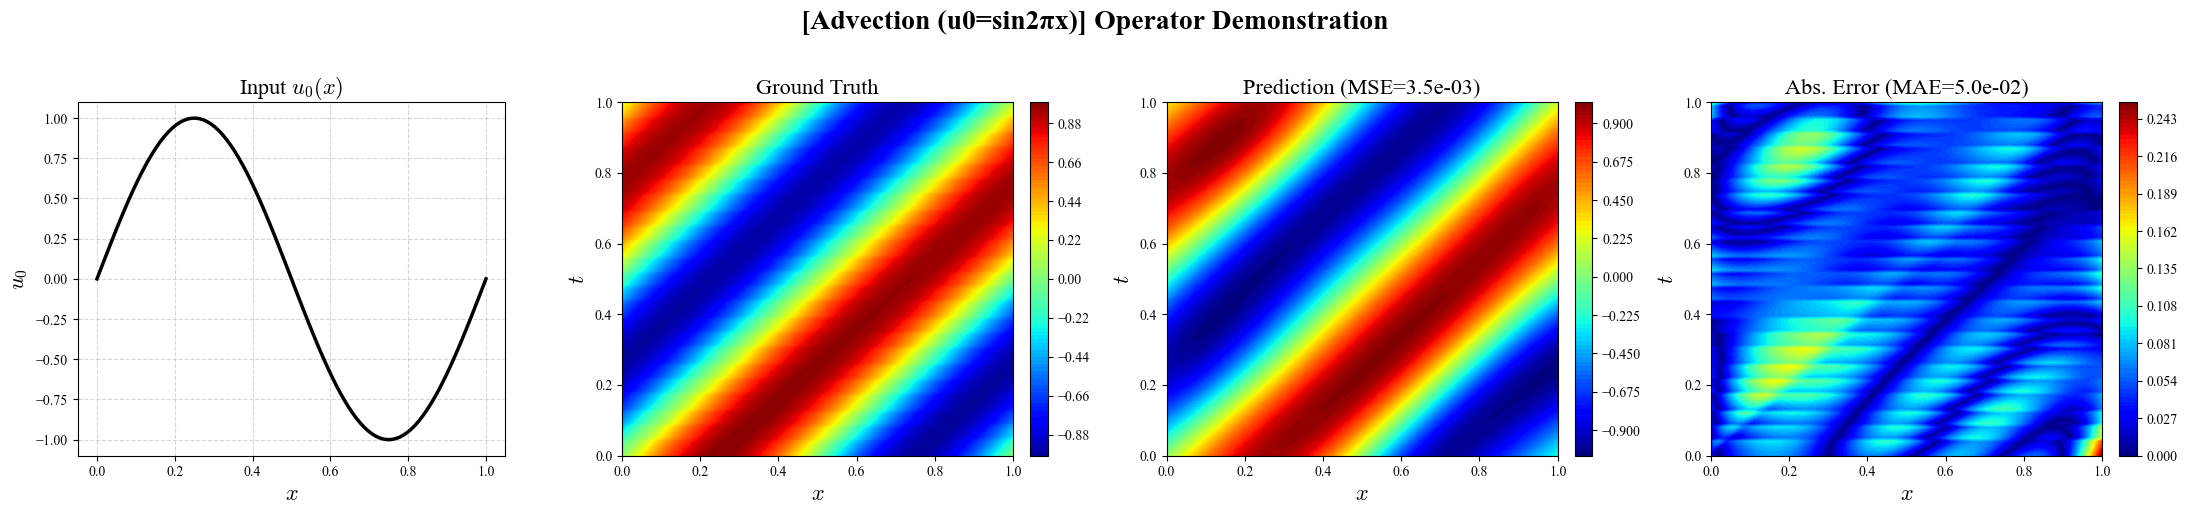

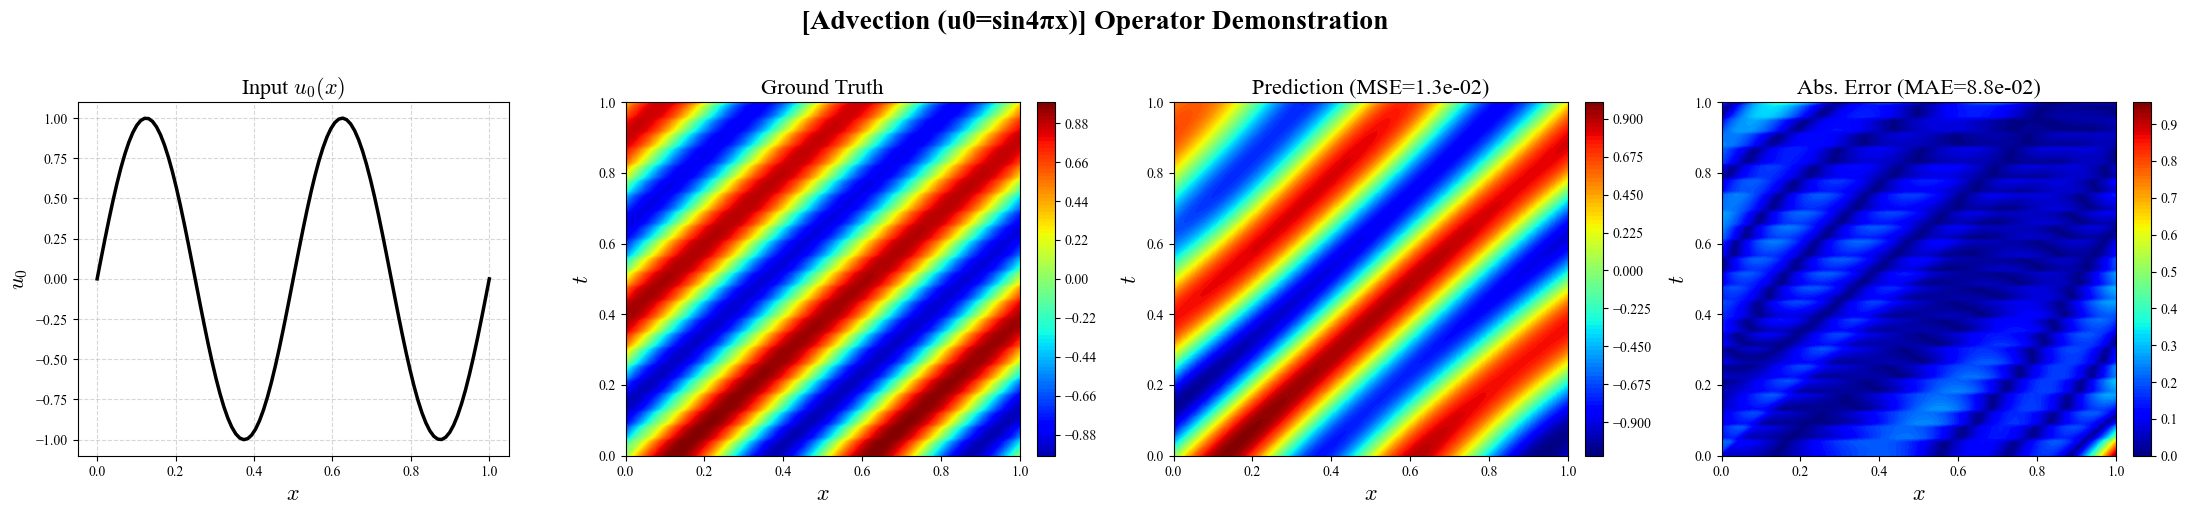


Processing RDiffusion...


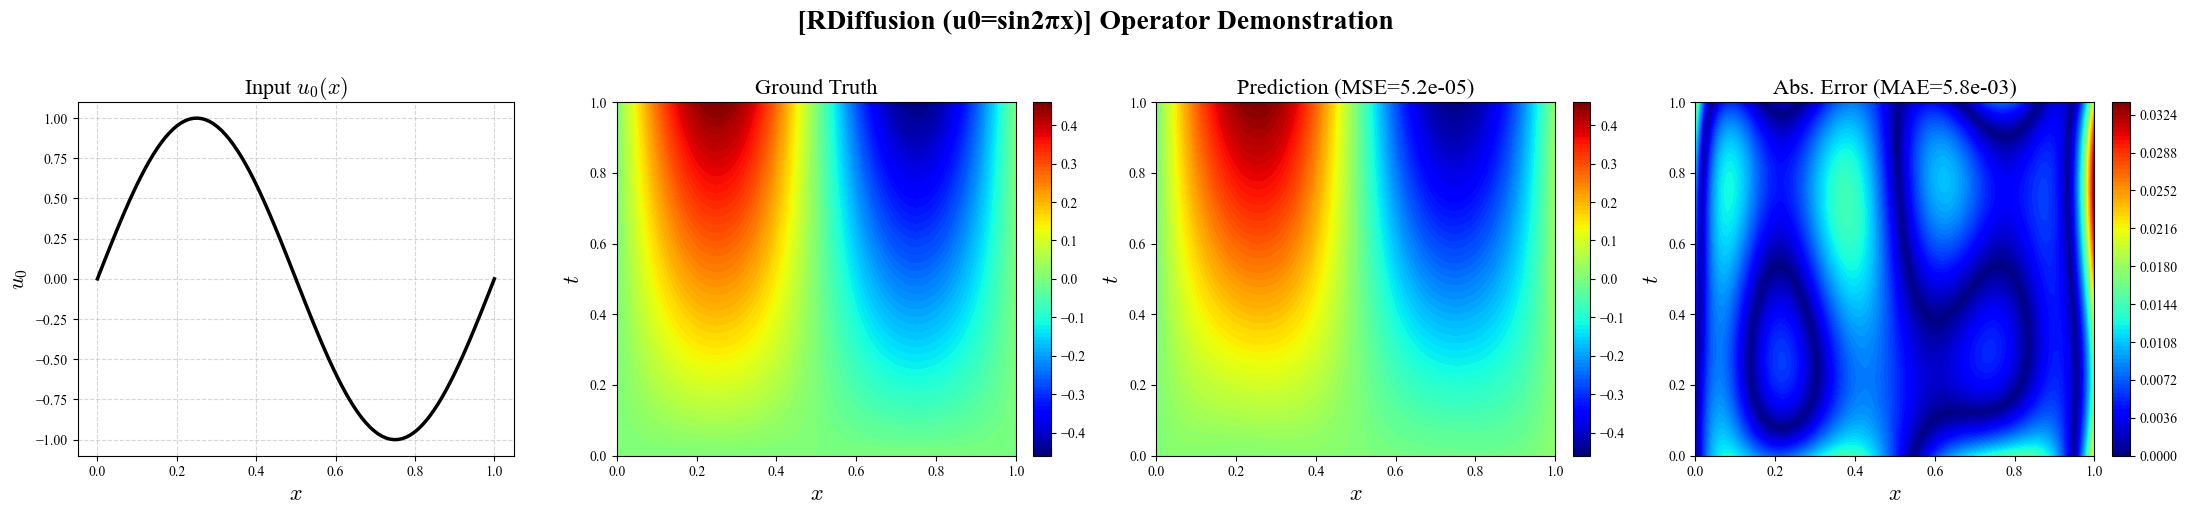

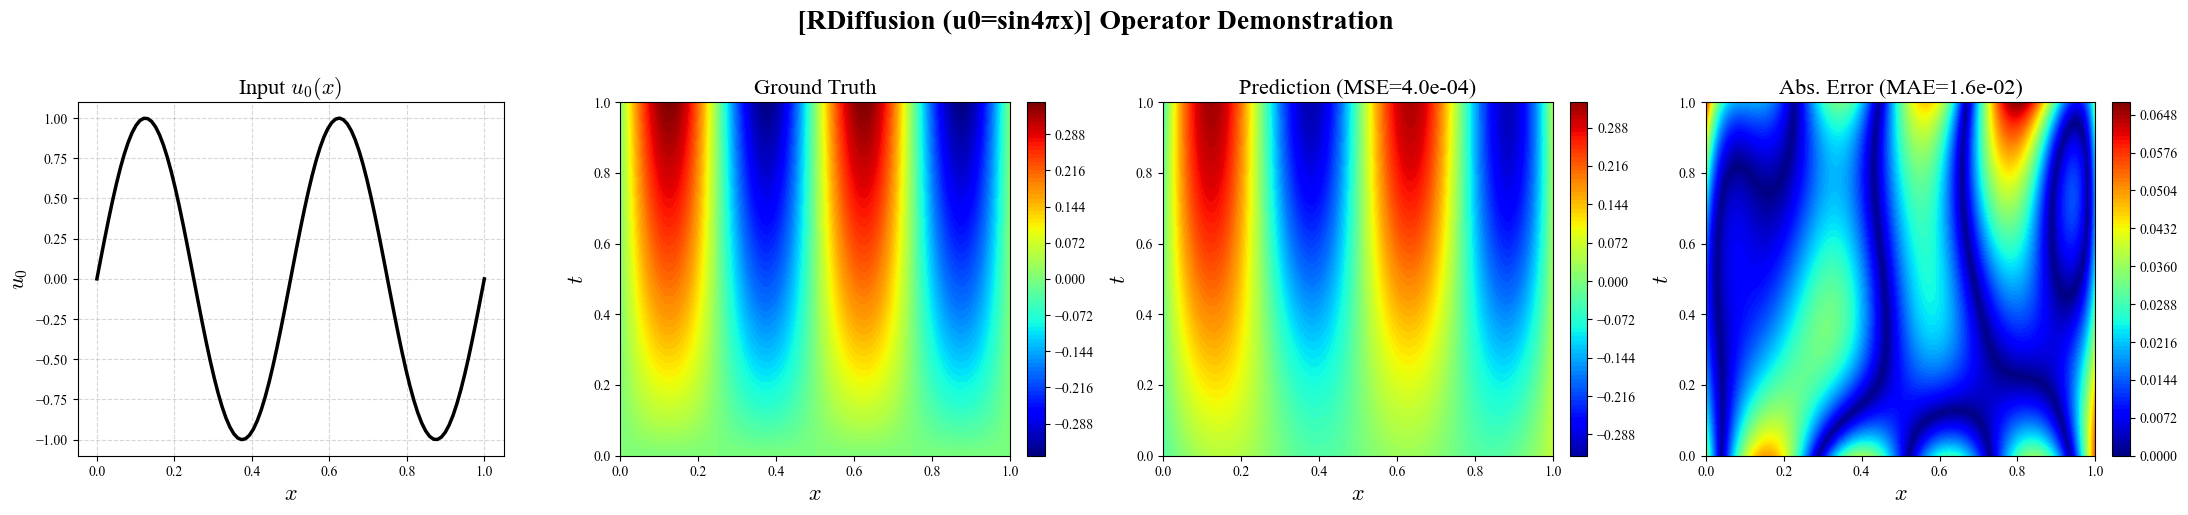


Processing Darcy...


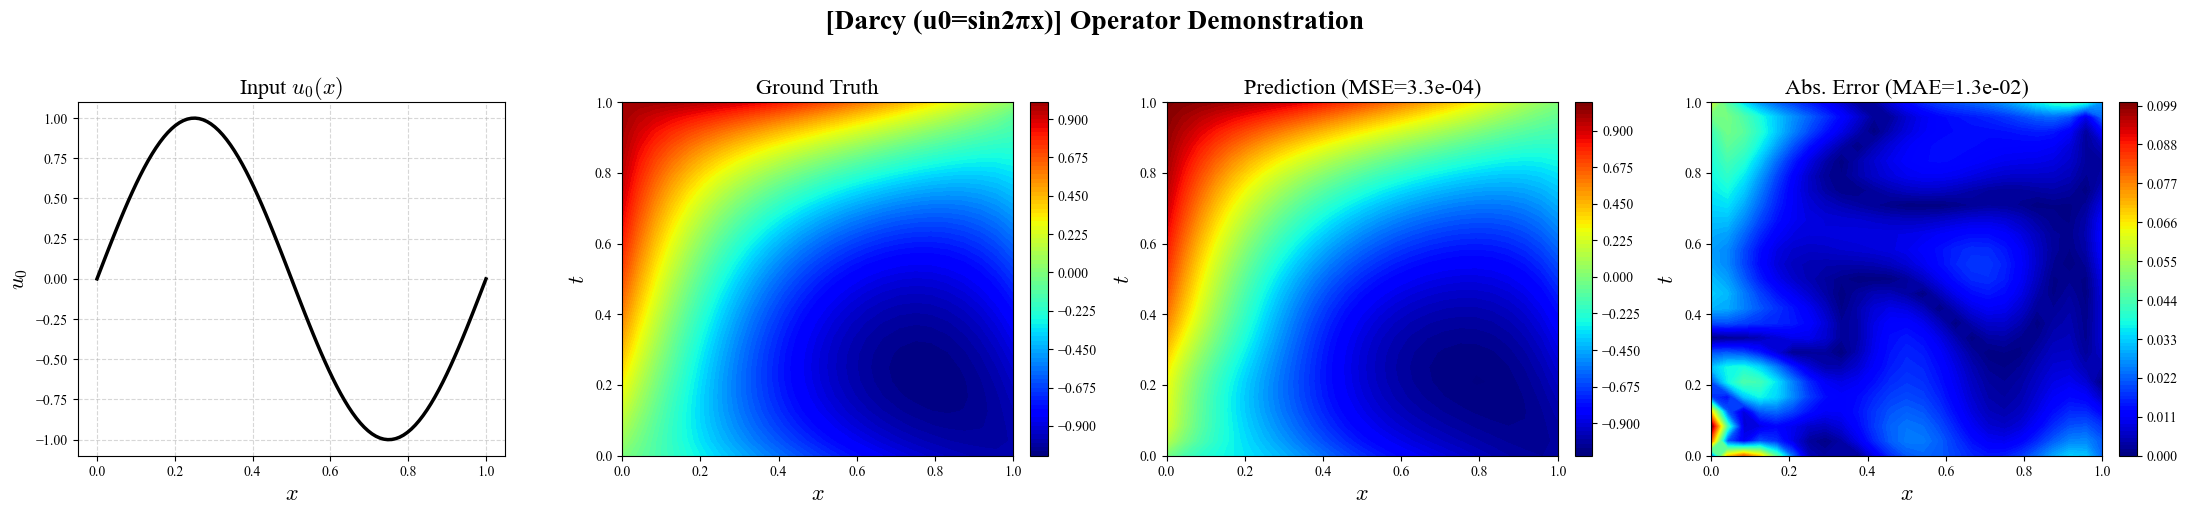

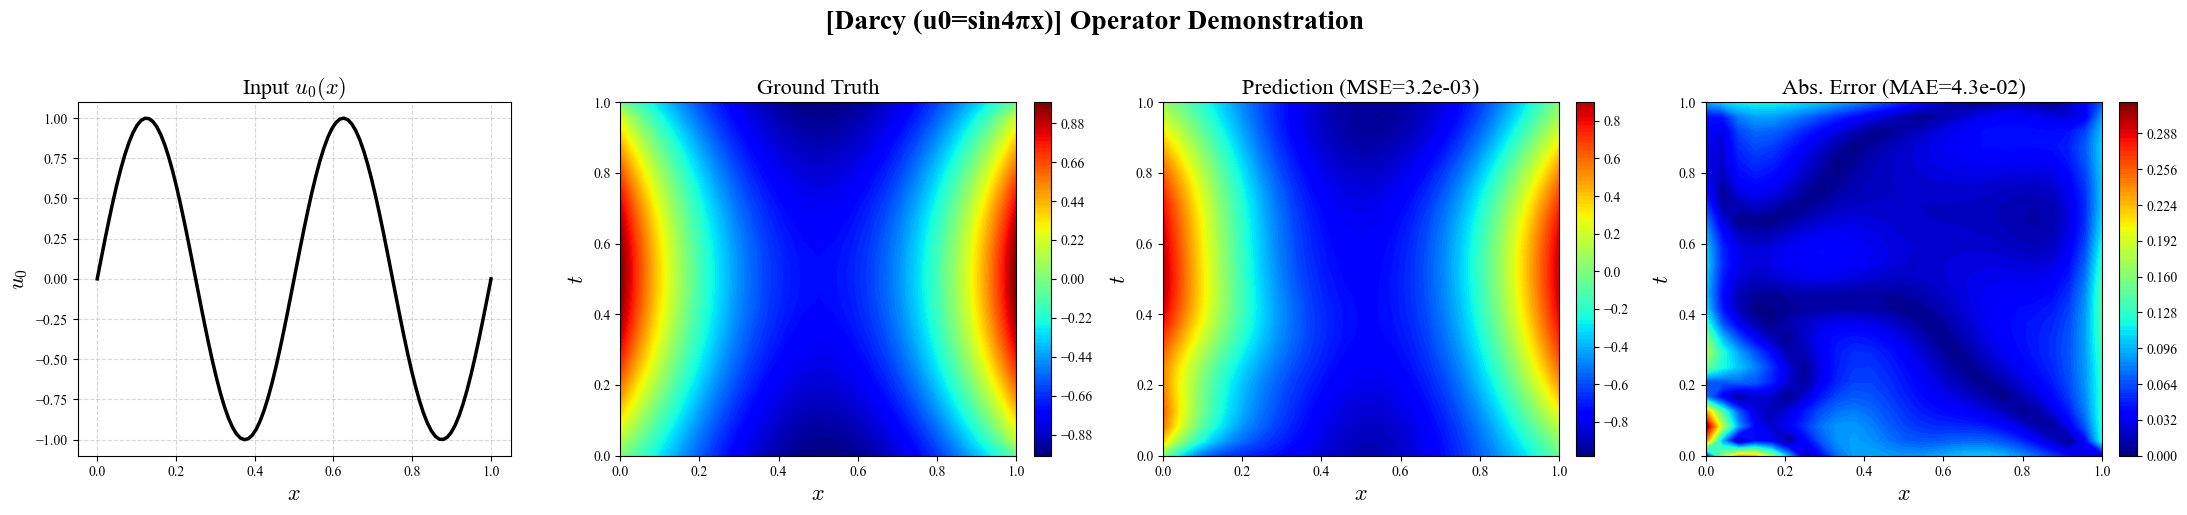

In [20]:
# Set up the calibration input (OOD) for 2D PDEs
num_points_0 = 100
pde_operators = ['Advection', 'RDiffusion', 'Darcy']

# Define OOD input functions for 2D PDEs
ood_input_definitions = {
    'u0=sin2πx' : lambda x: np.sin(2 * np.pi * x),
    'u0=sin4πx': lambda x: np.sin(4* np.pi * x)
}


for operator in pde_operators:
    num_points = 25 if operator == 'Darcy' else 100
    x_cal_0 = np.linspace(0, 1, num_points_0).astype(np.float32)
    x_cal = np.linspace(0, 1, num_points).astype(np.float32)
    other_grid_cal = np.linspace(0, 1, num_points).astype(np.float32) # Darcy->y, Others->t
    X_grid, YT_grid = np.meshgrid(x_cal, other_grid_cal)

    trunk_input_np = np.hstack((X_grid.flatten()[:, None], YT_grid.flatten()[:, None]))
    trunk_input = ms.Tensor(trunk_input_np, ms.float32)

    print(f"\nProcessing {operator}...")
    cfg = problem_configs[operator]
    if_Save = cfg.get('ckpt_path') and os.path.exists(cfg['ckpt_path'])
    if not if_Save:
        print(f"Skipping {operator} - CKPT not found."); continue

    # Create Model
    ham = generate_simple_hamiltonian(cfg['num_qubits'], -5, 5, 'Z')
    model = QuanONet(cfg['num_qubits'], 100, 2, cfg['net_size'], ham, cfg['scale_coeff'], if_trainable_freq=True)
    load_param_into_net(model, load_checkpoint(cfg['ckpt_path']), strict_load=False)
    model.set_train(False)

    for input_name, input_func in ood_input_definitions.items():
        u0_vis = input_func(x_cal_0)
        
        # Generate True Solution Grid (100x100)
        raw_true_sol, _ = cfg['pde_solver'](num_points, 0.2, u0_cal=u0_vis, **cfg['solver_args'])
        true_sol_np = raw_true_sol.T 
        
        # Prediction
        branch_input_np = np.tile(u0_vis, (trunk_input_np.shape[0], 1))
        branch_input = ms.Tensor(branch_input_np, ms.float32)
        pred_sol_ms = model((branch_input, trunk_input))
        pred_sol_np = pred_sol_ms.asnumpy().reshape(num_points, num_points)
        
        # Compute MAE/MSE
        diff = true_sol_np - pred_sol_np
        mae = np.mean(np.abs(diff))
        mse = np.mean(diff**2)
        
        # Plotting
        plot_operator_result(
            f"{operator} ({input_name})", true_sol_np, pred_sol_np, 
            u0_vis, x_cal, other_grid_cal, mae, mse
        )

In [ ]:
import os
# 强制设定 DeepXDE 后端为 PyTorch
os.environ["DDE_BACKEND"] = "pytorch"

import torch
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# 导入数据生成器
from data_utils.data_generation import solve_darcy_pde, solve_advection_pde, solve_rdiffusion_pde

# 绘图全局设置
plt.rcdefaults()
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

def plot_operator_result(operator_name, true_sol, pred_sol, u0_func_np, x_grid, other_grid, mae, mse):
    """画图函数保持与你原来的一模一样"""
    num_points = len(x_grid)
    num_points_0 = len(u0_func_np)
    x_cal_0 = np.linspace(0, 1, num_points_0).astype(np.float32)
    
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    vmin = min(true_sol.min(), pred_sol.min())
    vmax = max(true_sol.max(), pred_sol.max())
    ylabel = r"$t$" if 'Darcy' not in operator_name else r"$y$"
        
    # 1. Input u0
    axes[0].plot(x_cal_0, u0_func_np, 'k-', linewidth=2.5)
    axes[0].set_title(r"Input $u_0(x)$", fontsize=16)
    axes[0].set_xlabel(r"$x$", fontsize=16)
    axes[0].set_ylabel(r"$u_0$", fontsize=16)
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # 2. Ground Truth
    h1 = axes[1].contourf(x_grid, other_grid, true_sol, 100, cmap='jet', vmin=vmin, vmax=vmax)
    axes[1].set_ylabel(ylabel, fontsize=16)
    fig.colorbar(h1, ax=axes[1], fraction=0.046, pad=0.04)
    axes[1].set_title("Ground Truth", fontsize=16)
    axes[1].set_xlabel(r"$x$", fontsize=16)

    # 3. Prediction
    h2 = axes[2].contourf(x_grid, other_grid, pred_sol, 100, cmap='jet', vmin=vmin, vmax=vmax)
    axes[2].set_ylabel(ylabel, fontsize=16)
    fig.colorbar(h2, ax=axes[2], fraction=0.046, pad=0.04)
    axes[2].set_title(f"Prediction (MSE={mse:.1e})", fontsize=16)
    axes[2].set_xlabel(r"$x$", fontsize=16)

    # 4. Abs. Error
    abs_error_grid = np.abs(true_sol - pred_sol)
    h3 = axes[3].contourf(x_grid, other_grid, abs_error_grid, 100, cmap='jet')
    axes[3].set_ylabel(ylabel, fontsize=16)
    fig.colorbar(h3, ax=axes[3], fraction=0.046, pad=0.04)
    axes[3].set_title(f"Abs. Error (MAE={mae:.1e})", fontsize=16)
    axes[3].set_xlabel(r"$x$", fontsize=16)

    plt.suptitle(f"[{operator_name}] Operator Demonstration", fontsize=20, y=1.02, fontweight='bold')
    plt.tight_layout()
    plt.show()
# 测试函数
ood_input_definitions = {
    'u0=sin2πx' : lambda x: np.sin(2 * np.pi * x),
    'u0=sin4πx': lambda x: np.sin(4 * np.pi * x)
}

# PDE 经典模型配置 (基于你 reproduce_table4.sh 中 PDE 的 NET_SIZE)
# DeepONet: "3 15 3 15" -> Branch[100, 15, 15, 15], Trunk[2, 15, 15, 15]
# FNN: "3 16" -> Layer_sizes[102, 16, 16, 16, 1]

problem_configs = {
    'Advection': {
        'DeepONet_ckpt': "Table4_Reproduction/Advection/Advection_DeepONet_Net3-15-3-15_1000x100_Seed0/best_model.pt",
        'FNN_ckpt': "Table4_Reproduction/Advection/Advection_FNN_Net3-16_1000x100_Seed0/best_model.pt",
        'pde_solver': solve_advection_pde,
        'solver_args': {'c': 1.0}
    },
    'RDiffusion': {
        'DeepONet_ckpt': "Table4_Reproduction/RDiffusion/RDiffusion_DeepONet_Net3-15-3-15_1000x100_Seed0/best_model.pt",
        'FNN_ckpt': "Table4_Reproduction/RDiffusion/RDiffusion_FNN_Net3-16_1000x100_Seed0/best_model.pt",
        'pde_solver': solve_rdiffusion_pde,
        'solver_args': {'D': 0.01, 'k': 0.01}
    },
    'Darcy': {
        'DeepONet_ckpt': "Table4_Reproduction/Darcy/Darcy_DeepONet_Net3-15-3-15_1000x100_Seed0/best_model.pt",
        'FNN_ckpt': "Table4_Reproduction/Darcy/Darcy_FNN_Net3-16_1000x100_Seed0/best_model.pt",
        'pde_solver': solve_darcy_pde,
        'solver_args': {'K': 0.1, 'f': -1.0}
    }
}
pde_operators = ['Advection', 'RDiffusion', 'Darcy']
models_to_test = ['DeepONet', 'FNN']

for operator in pde_operators:
    num_points = 25 if operator == 'Darcy' else 100
    num_points_0 = 100
    x_cal_0 = np.linspace(0, 1, num_points_0).astype(np.float32)
    x_cal = np.linspace(0, 1, num_points).astype(np.float32)
    other_grid_cal = np.linspace(0, 1, num_points).astype(np.float32)
    X_grid, YT_grid = np.meshgrid(x_cal, other_grid_cal, indexing='ij')

    # 生成 Trunk (坐标) 输入 -> shape (Points^2, 2)
    trunk_input_np = np.hstack((X_grid.flatten()[:, None], YT_grid.flatten()[:, None]))
    trunk_tensor = torch.tensor(trunk_input_np, dtype=torch.float32)

    cfg = problem_configs[operator]

    for model_name in models_to_test:
        ckpt_path = cfg.get(f'{model_name}_ckpt')
        if not ckpt_path or not os.path.exists(ckpt_path):
            print(f"⚠️ 找不到 {operator} 的 {model_name} 权重，已跳过。路径：{ckpt_path}")
            continue
            
        print(f"\n======================================")
        print(f"📊 正在生成: {operator} - {model_name}")
        print(f"======================================")

        # 1. 实例化 DeepXDE 模型结构
        if model_name == 'DeepONet':
            # PDE 配置: Branch [100, 15, 15, 15], Trunk [2, 15, 15, 15]
            layer_size_branch = [100, 15, 15, 15]
            layer_size_trunk = [2, 15, 15, 15]
            net = dde.nn.DeepONet(layer_size_branch, layer_size_trunk, "relu", "Glorot normal")
        elif model_name == 'FNN':
            # PDE 配置: Input 102, Hidden 16x3, Output 1
            layer_sizes = [102, 3, 16, 1]
            net = dde.nn.FNN(layer_sizes, "relu", "Glorot normal")

        # 2. 加载 PyTorch 权重
        state_dict = torch.load(ckpt_path, map_location=torch.device('cpu'))
        net.load_state_dict(state_dict)
        net.eval() # 开启评估模式

        # 3. 对不同输入函数进行推理
        for input_name, input_func in ood_input_definitions.items():
            u0_vis = input_func(x_cal_0)
            
            # 生成 True Solution
            raw_true_sol, _ = cfg['pde_solver'](num_points, 0.2, u0_cal=u0_vis, **cfg['solver_args'])
            true_sol_np = raw_true_sol.T 
            
            # 生成 Branch (函数特征) 输入 -> shape (Points^2, 100)
            branch_input_np = np.tile(u0_vis, (trunk_input_np.shape[0], 1))
            branch_tensor = torch.tensor(branch_input_np, dtype=torch.float32)

            # 4. 执行前向传播
            with torch.no_grad():
                if model_name == 'DeepONet':
                    pred_sol_pt = net((branch_tensor, trunk_tensor))
                elif model_name == 'FNN':
                    # FNN 需要大乱炖拼接：(10000, 102)
                    concat_tensor = torch.cat([branch_tensor, trunk_tensor], dim=1)
                    pred_sol_pt = net(concat_tensor)
            
            # 还原为二维网格
            # 修改后：拉回 CPU 并转换为 Numpy
            pred_sol_np = pred_sol_pt.cpu().detach().numpy().reshape(num_points, num_points).T
            
            # 计算误差
            diff = true_sol_np - pred_sol_np
            mae = np.mean(np.abs(diff))
            mse = np.mean(diff**2)
            
            # 绘图
            plot_operator_result(
                f"{operator} - {model_name} ({input_name})", true_sol_np, pred_sol_np, 
                u0_vis, x_cal, other_grid_cal, mae, mse
            )